In [60]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
import torch
import json
import os
from torch_geometric.nn import global_mean_pool
import src.global_config as global_cfg
import src.stats.config as cfg
import src.gnn.embedding_config as ecfg
import src.gnn.model as sage
import src.gnn.data as gnnDataLoader
import src.gnn.train as train
import src.gnn.pipeline as pipeline
import src.gnn.embedding_analysis as eanalysis
import src.gnn.embedding_viz as eviz
import src.stats.analysis as stat_analysis
import src.stats.visualization as stat_viz

In [62]:
with open("./Data/BN/network_2003.json", "r") as f:
    raw_json = json.load(f)

snapshot_2003 = gnnDataLoader.json_to_pyg_data(raw_json)
print(f"Snapshot creado: {snapshot_2003}")
print(f"Nodos: {snapshot_2003.num_nodes}, Features: {snapshot_2003.num_node_features}")

Snapshot creado: Data(x=[397, 8], edge_index=[2, 396], edge_attr=[396, 1])
Nodos: 397, Features: 8


In [63]:
data = snapshot_2003
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)
data = data.to(device)

Usando dispositivo: cuda


In [64]:


model = sage.GraphSAGEEncoder(ecfg.IN_CHANNELS, ecfg.HIDDEN_CHANNELS, ecfg.OUT_CHANNELS, ecfg.DROPOUT_RATE).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=ecfg.LR_INITIAL, weight_decay=ecfg.WEIGHT_DECAY)
criterion = torch.nn.BCEWithLogitsLoss()

In [65]:
trained_model = train.train_linkpred(model, data, optimizer,  criterion, device, epochs=200)
trained_model.eval()
with torch.no_grad():
    z = trained_model(data.x, data.edge_index)  # [num_nodes, out_channels]

embeddings = z.cpu().numpy()
print("dimension de embeddings:", embeddings.shape)  # (num_nodes, out_channels)
print(embeddings[0])

items = raw_json["network"]["items"]
clusters = [node.get("cluster", -1) for node in items]  # lista de clusters


Epoch 001 | Loss: 0.5259
Epoch 020 | Loss: 0.4072
Epoch 040 | Loss: 0.3796
Epoch 060 | Loss: 0.3871
Epoch 080 | Loss: 0.3686
Epoch 100 | Loss: 0.3574
Epoch 120 | Loss: 0.3644
Epoch 140 | Loss: 0.3703
Epoch 160 | Loss: 0.3546
Epoch 180 | Loss: 0.3659
Epoch 200 | Loss: 0.3578
dimension de embeddings: (397, 8)
[  0.674497   -41.439045   -29.160183    -9.723061    -6.360831
  14.547762    -8.1272545    0.30134338]


In [66]:

# z ya existe, NO usamos z_nodes aquí
ego_mask = gnnDataLoader.get_ego_mask(raw_json).to(device)

# Filtrar solo alters
z_alters = z[ego_mask]

# Nuevo batch: todos los alters pertenecen al mismo grafo
batch_alters = torch.zeros(z_alters.size(0), dtype=torch.long, device=device)

graph_embedding = global_mean_pool(z_alters, batch_alters)

print("Dimension del embedding del grafo (sin ego):", graph_embedding.shape)
print(graph_embedding)


# Crear el vector batch (todos los nodos tienen la etiqueta 0 porque es un solo grafo)
# z es la matriz de embeddings de todos los nodos, es de la forma [No.Nodos, out_channels]
print(z.shape)
#batch = torch.zeros(data.num_nodes, dtype=torch.long, device=device)

# Hacemos el pooling usando los embeddings de nodos ya entrenados (z)
# El pooling hace un "promedio" en base al tamaño del batch, en nuestro caso
# al poner batch como un tensor llenos de 0's, entonces promedia todos aquellos que tengan como indice 0 (todos los nodos)
#Devuelve una matriz de [1, 16], "comprime" todos los embeddings a uno solo
#graph_embedding = global_mean_pool(z, batch)
print("Dimension del embedding del grafo:", graph_embedding.shape)
print(graph_embedding)

Dimension del embedding del grafo (sin ego): torch.Size([1, 8])
tensor([[ 0.0037, -0.0980, -0.0733, -0.0225, -0.0101,  0.0303, -0.0146, -0.0069]],
       device='cuda:0')
torch.Size([397, 8])
Dimension del embedding del grafo: torch.Size([1, 8])
tensor([[ 0.0037, -0.0980, -0.0733, -0.0225, -0.0101,  0.0303, -0.0146, -0.0069]],
       device='cuda:0')


In [67]:
#Entrenar red y generar embeddings
historia = pipeline.run_temporal_graphsage(device)

Modo: con memoria
Epoch 001 | Loss: 0.5723
Epoch 020 | Loss: 0.4833
Epoch 040 | Loss: 0.4983
Epoch 060 | Loss: 0.6217
1980 procesado.
Epoch 001 | Loss: 0.4710
Epoch 020 | Loss: 0.4779
Epoch 040 | Loss: 0.4153
Epoch 060 | Loss: 0.4332
1981 procesado.
Epoch 001 | Loss: 0.5253
Epoch 020 | Loss: 0.3979
Epoch 040 | Loss: 0.4209
Epoch 060 | Loss: 0.4478
1982 procesado.
Epoch 001 | Loss: 0.4306
Epoch 020 | Loss: 0.4507
Epoch 040 | Loss: 0.4207
Epoch 060 | Loss: 0.4379
1983 procesado.
Epoch 001 | Loss: 0.4995
Epoch 020 | Loss: 0.4070
Epoch 040 | Loss: 0.4622
Epoch 060 | Loss: 0.3743
1984 procesado.
Epoch 001 | Loss: 0.3816
Epoch 020 | Loss: 0.4196
Epoch 040 | Loss: 0.4112
Epoch 060 | Loss: 0.4020
1985 procesado.
Epoch 001 | Loss: 0.4494
Epoch 020 | Loss: 0.4217
Epoch 040 | Loss: 0.4252
Epoch 060 | Loss: 0.5101
1986 procesado.
Epoch 001 | Loss: 0.4668
Epoch 020 | Loss: 0.3840
Epoch 040 | Loss: 0.3766
Epoch 060 | Loss: 0.3690
1987 procesado.
Epoch 001 | Loss: 0.3787
Epoch 020 | Loss: 0.3780
Epoc

In [68]:
print(graph_embedding.shape)

torch.Size([1, 8])


In [69]:
df_trayectoria = eanalysis.calcular_pca_2d(historia)
eviz.plot_trayectoria_2d(df_trayectoria)

In [70]:
df_flujo = eanalysis.calcular_pca_1d(historia)
eviz.plot_evolucion_pc1(df_flujo)

In [71]:
# Guardar serie PC1 de GraphSAGE por año
df_sage = df_flujo.rename(columns={"y_original": "sage_pc1"}).copy()
df_sage.to_csv(os.path.join(ecfg.OUTPUT_DIR, "graphsage_pca1.csv"), index=False)
print(f"[OK] Guardado en: {ecfg.OUTPUT_DIR}")


[OK] Guardado en: ./Output


Calculando promedios anuales de los datos crudos...
PC1 ya estaba alineado con 'Percent of documents'. Corr: 0.5523

Resultados de Correlación con el Eje Y PC1
WoS Categories: 0.0179
Document Types: 0.0390
Documents,: 0.1746
Ave. citations: 0.2333
Ave. authorships: -0.3747
Ave. references: 0.0952
Percent of documents: 0.5523
Percent of documents Int. Coll.: -0.4806


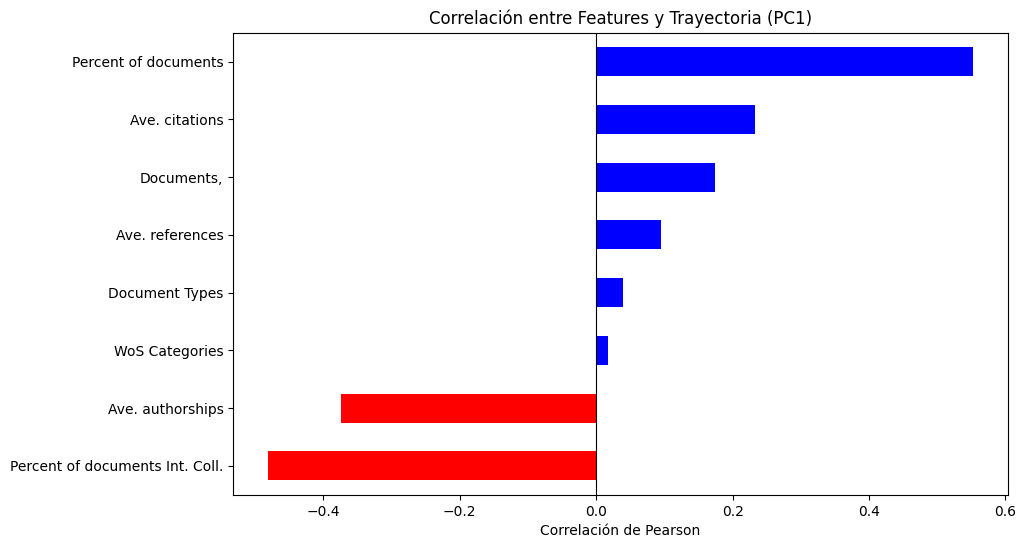

In [72]:
nombres_features = [f[1] for f in global_cfg.FEATURES]
df_features = eanalysis.obtener_promedios_anuales(df_flujo['year'].values, nombres_features, ecfg.DATA_FOLDER)
df_flujo, correlaciones = eanalysis.correlacionar_y_alinear(df_flujo, df_features, ecfg.ALIGN_PC1_ANCHOR)

eviz.plot_correlaciones_barras(correlaciones)

In [73]:
print(df_features)

      WoS Categories  Document Types  Documents,  Ave. citations  \
1980        4.592593        1.666667    5.814815       25.018519   
1981        3.687500        1.500000    5.296875       26.009219   
1982        4.779661        1.525424    6.593220       86.254407   
1983        4.138889        1.444444    5.750000       47.642222   
1984        3.739130        1.500000    5.413043       38.248913   
1985        4.294118        1.529412    7.264706       29.074706   
1986        5.578947        1.526316   11.684211       23.662632   
1987        5.435540        1.843206    8.094077       41.162613   
1988        4.596899        1.627907    4.689922       39.926279   
1989        3.741935        1.435484    4.790323       20.731452   
1990        4.523256        1.546512    4.883721       41.865000   
1991        5.428571        1.816327    8.408163       26.337388   
1992        5.284444        1.715556    7.280000       30.240400   
1993        4.115385        1.576923    5.923077

In [74]:
#Percent of documents resultó  tener una correlación bastante alta, por lo tanto, las gráficas
#deberían ser bastante parecidas (la generada por pca y la que es a partir de los datos crudos)
#"Ave. authorships"
# 5. Gráficas de Comparación
df_plot, df_comparacion = eanalysis.preparar_datos_comparacion(df_features, df_flujo)
eviz.plot_feature_individual(df_plot, ecfg.ALIGN_PC1_ANCHOR)
eviz.plot_comparacion_normalizada(df_comparacion)

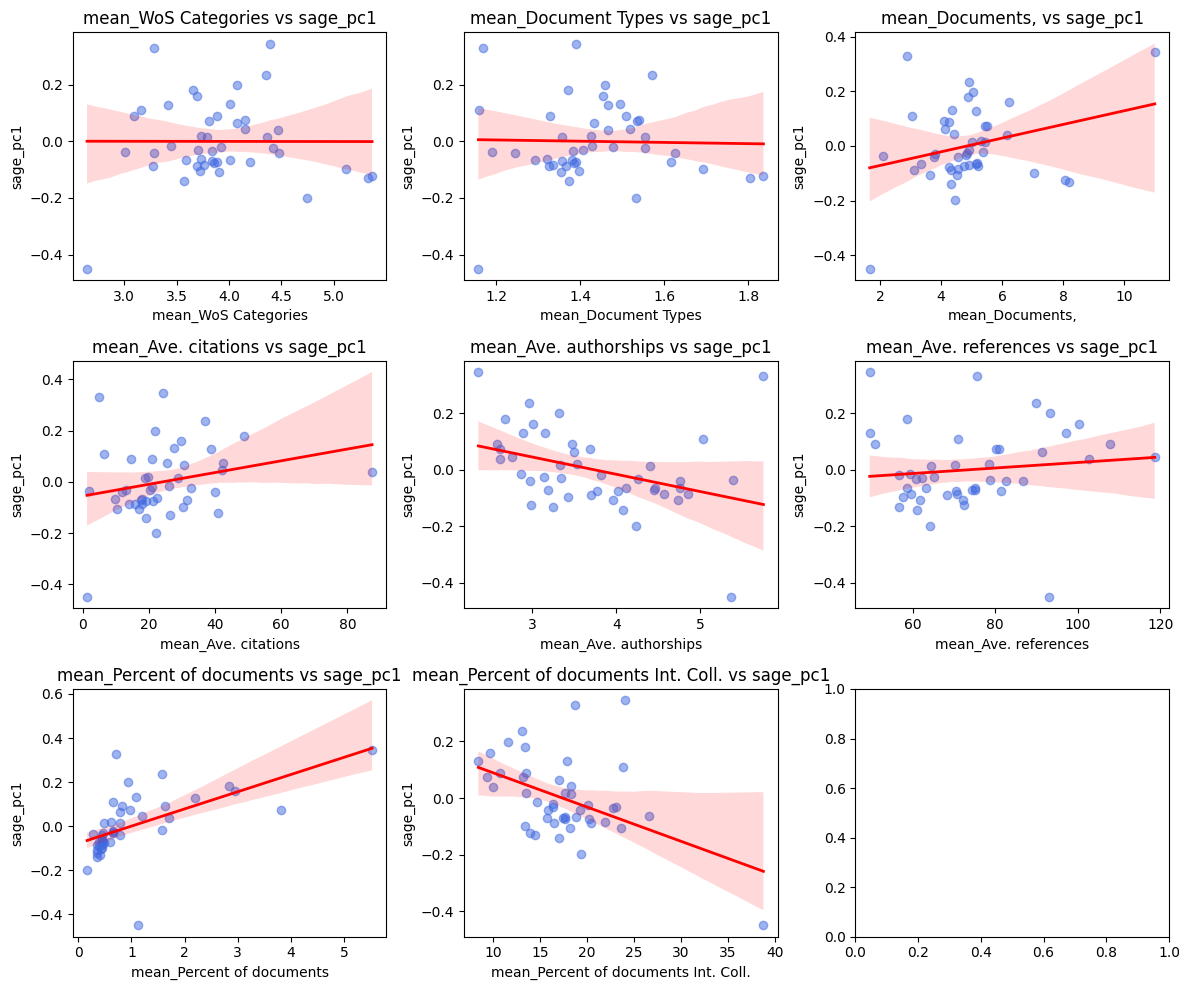

In [75]:
df_all = stat_analysis.cargar_y_unir_datos(cfg.LEVEL) #cargamos y preparamos los datos
#Exploración visual inicial
stat_viz.plot_dispersion_ols(df_all, 'mean_Percent of documents', 'sage_pc1')
# Los candidatos son exactamente los features definidos para hacer el embedding de sage
features_candidatas = [f"mean_{tupla[1]}" for tupla in global_cfg.FEATURES] # Extraemos el segundo elemento de la tupla (tupla[1]) y le pegamos "mean_"
stat_viz.plot_matriz_features(df_all, features_candidatas)

In [76]:
# Modelos OLS
# Múltiple sin HAC
modelo_mult = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents', 'mean_Ave. authorships'])
print(modelo_mult.summary())
#y = df_all['sage_pc1']  #variable objetivo
#X = df_all[['mean_Percent of documents', 'mean_Ave. authorships']] #Variables predictoras

# Le ponemos su constante 
#Ecuacion lineal de la forma y=b0 + b1x1 + b2x2 donde los xn son los atributos
#X = sm.add_constant(X) #cada atributo definido en X es un valor asociado a x_n, b0 es la constante (lo definimos como 1), b1 y b2 son los valores a estimar
#modelo = sm.OLS(y, X).fit()
#print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.306
Method:                 Least Squares   F-statistic:                     10.72
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           0.000174
Time:                        00:26:13   Log-Likelihood:                 34.624
No. Observations:                  45   AIC:                            -63.25
Df Residuals:                      42   BIC:                            -57.83
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [77]:

# Múltiple sin HAC
modelo_mult = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents', 'mean_Ave. authorships'])
print(modelo_mult.summary())


                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.338
Model:                            OLS   Adj. R-squared:                  0.306
Method:                 Least Squares   F-statistic:                     10.72
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           0.000174
Time:                        00:26:13   Log-Likelihood:                 34.624
No. Observations:                  45   AIC:                            -63.25
Df Residuals:                      42   BIC:                            -57.83
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [78]:
# Simple con HAC
modelo_simple = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents'], usar_hac=True, maxlags=3)
print(modelo_simple.summary())

                            OLS Regression Results                            
Dep. Variable:               sage_pc1   R-squared:                       0.335
Model:                            OLS   Adj. R-squared:                  0.319
Method:                 Least Squares   F-statistic:                     45.66
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           2.89e-08
Time:                        00:26:13   Log-Likelihood:                 34.522
No. Observations:                  45   AIC:                            -65.04
Df Residuals:                      43   BIC:                            -61.43
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

------------------------------------------------------------
Diagnostico de residuos
------------------------------------------------------------
Prueba de Durbin-Watson (Independencia): 1.313
Prueba de Shapiro-Wilk (Normalidad): p-value = 0.0000
Prueba de Breusch-Pagan (Homocedasticidad): p-value = 0.9077


/home/jose/miniconda3/envs/pateaAbuelitas/lib/python3.10/site-packages/statsmodels/graphics/gofplots.py:1041: UserWarning:

color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.



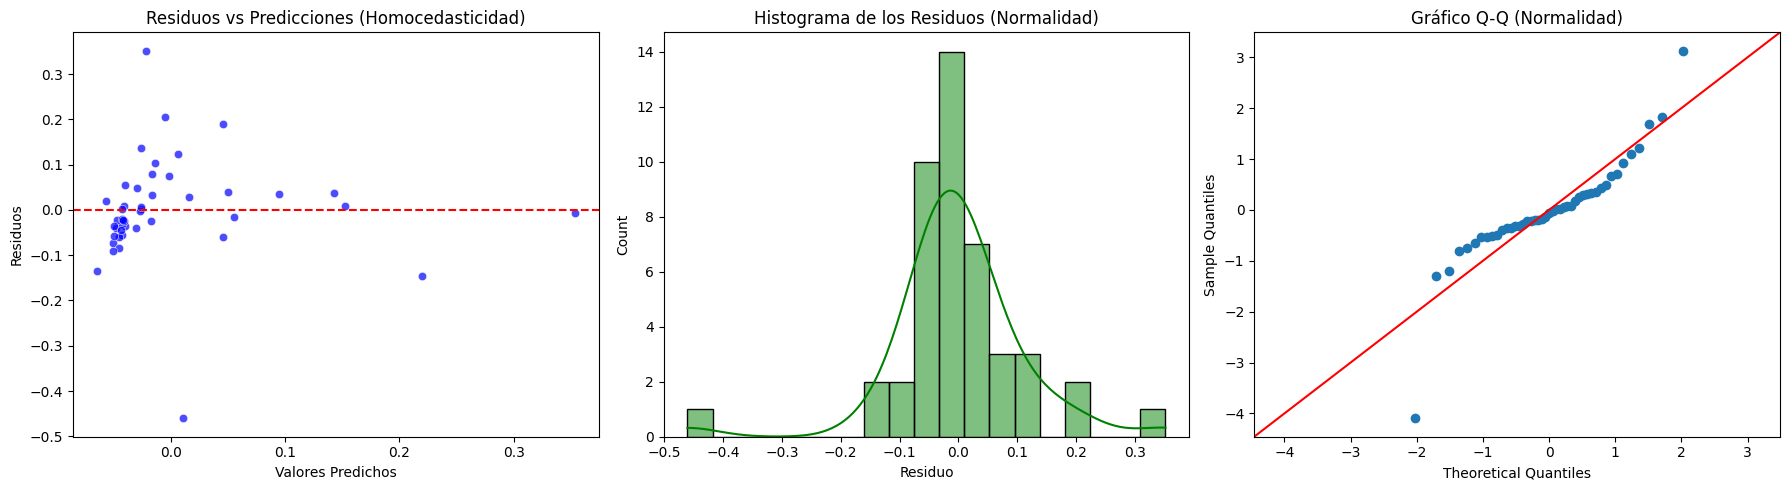

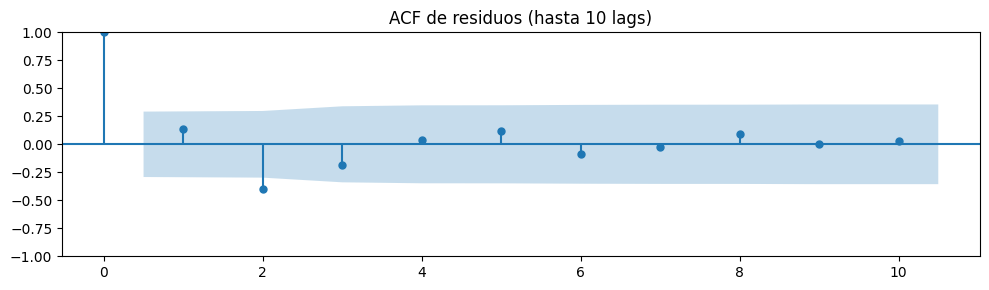

In [79]:
# Diagnóstico de residuos (del modelo simple normal para ver los errores puros)
modelo_base = stat_analysis.ajustar_modelo_ols(df_all, 'sage_pc1', ['mean_Percent of documents'])
residuos, predicciones = stat_analysis.ejecutar_diagnostico_residuos(modelo_base)

stat_viz.plot_panel_residuos(predicciones, residuos)
stat_viz.plot_acf_residuos(df_all, residuos)